In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [21]:
file_path = 'Seasons_Stats.csv'
df1 = pd.read_csv(file_path)



In [18]:
df1.head()


,name,year_start,year_end,position,height,weight,birth_date,college
0,Alaa Abdelnaby,1991,1995,F-C,6-10,240.0,"June 24, 1968",Duke University
1,Zaid Abdul-Aziz,1969,1978,C-F,6-9,235.0,"April 7, 1946",Iowa State University
2,Kareem Abdul-Jabbar,1970,1989,C,7-2,225.0,"April 16, 1947","University of California, Los Angeles"
3,Mahmoud Abdul-Rauf,1991,2001,G,6-1,162.0,"March 9, 1969",Louisiana State University
4,Tariq Abdul-Wahad,1998,2003,F,6-6,223.0,"November 3, 1974",San Jose State University


In [50]:
df_clean = df1[['Age', 'PTS', 'AST', 'Pos']].copy()
df_clean.dropna(inplace=True)
df_clean['Age'] = df_clean['Age'].astype(int)
df_clean['Simple_pos'] = df_clean['Pos'].str[0]
main_positions = ['G', 'F', 'C']
df_multivariate = df_clean[df_clean['Simple_pos'].isin(main_positions)]
df_clean.head()

,Age,PTS,AST,Pos,Simple_pos
0,31,458.0,176.0,G-F,G
1,29,279.0,109.0,SG,S
2,25,438.0,140.0,SF,S
3,24,63.0,20.0,F,F
4,24,59.0,20.0,F,F


Text(0, 0.5, 'PTS')

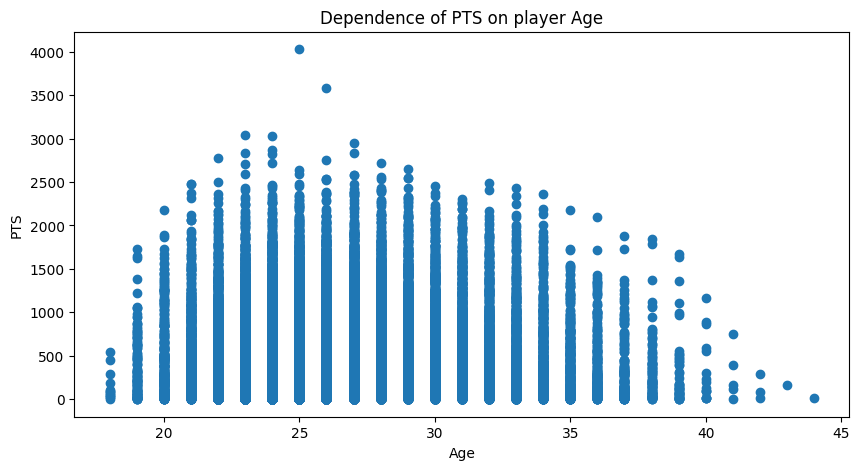

In [39]:
plt.figure(figsize = (10, 5))
plt.scatter(df_clean['Age'], df_clean['PTS'])
plt.title("Dependence of PTS on player Age")
plt.xlabel("Age")
plt.ylabel("PTS")


<Axes: xlabel='Age_group'>

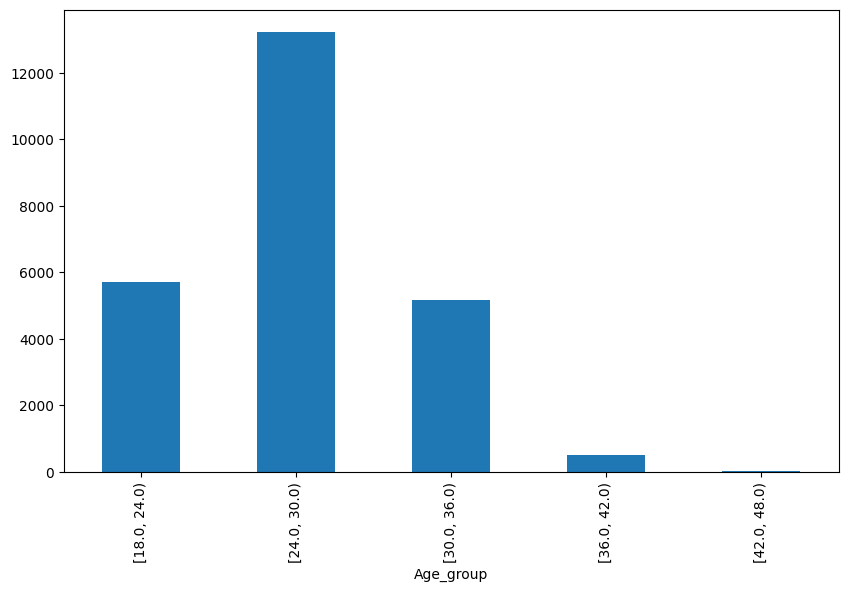

In [45]:
min_age = df_clean["Age"].min()
max_age = df_clean["Age"].max()
num_bins = 5
bin_width = np.ceil((max_age - min_age)/ num_bins)
bins = np.arange(min_age, max_age + bin_width + 1, bin_width)
df_clean["Age_group"] = pd.cut(df_clean['Age'], bins=bins, right=False, include_lowest=True)
age_count = df_clean["Age_group"].value_counts().sort_index()
plt.figure(figsize=(10, 6))
age_count.plot(kind="bar")



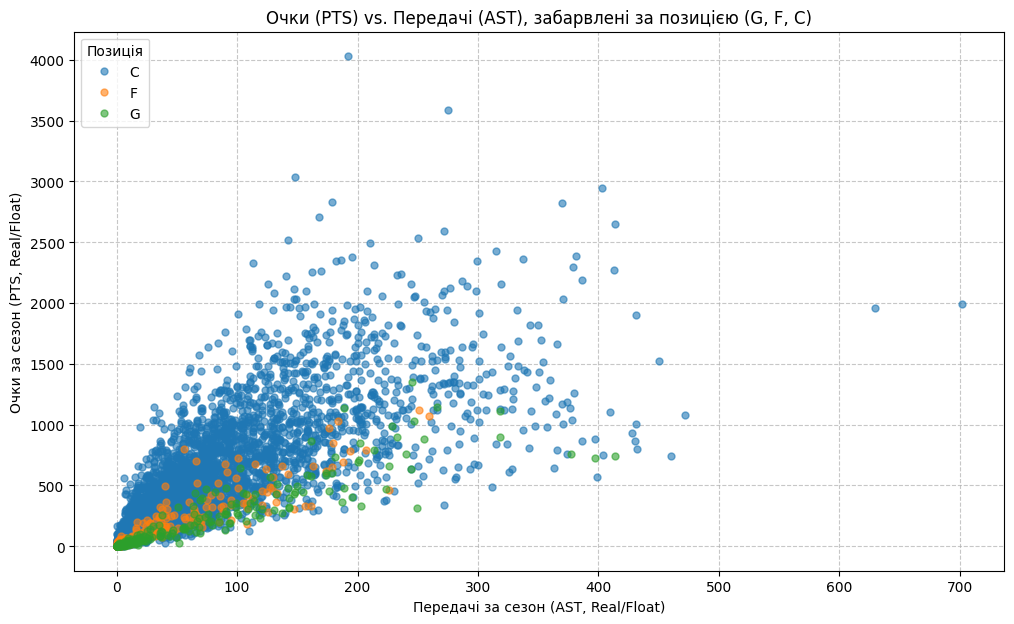

In [56]:
plt.figure(figsize=(12, 7))
groups = df_multivariate.groupby("Simple_pos")
for name,group in groups:
    plt.plot(group["AST"],group["PTS"],marker='o',linestyle='',ms=5,label=name, alpha=0.6)
plt.title('Очки (PTS) vs. Передачі (AST), забарвлені за позицією (G, F, C)')
plt.xlabel('Передачі за сезон (AST, Real/Float)')
plt.ylabel('Очки за сезон (PTS, Real/Float)')
plt.legend(title='Позиція', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)